In [1]:
# Cell 1: Imports
import os
import sys
import numpy as np
import librosa
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

# Thêm thư mục Scripts vào path để import preprocess
sys.path.append(str(Path("../Scripts").resolve()))
from preprocess import process_audio, FRAME_LENGTH, TARGET_SR

print("Imports OK")
print(f"FRAME_LENGTH = {FRAME_LENGTH} samples | TARGET_SR = {TARGET_SR} Hz")

Imports OK
FRAME_LENGTH = 16000 samples | TARGET_SR = 16000 Hz


In [2]:
# Cell 2: Load audio từ dataset đã split 
DATASET_DIR = Path("../dataset")
def load_wavs(folder):
    """Đọc toàn bộ file .wav trong folder, trả về list np.ndarray float32."""
    audios = []
    paths = sorted(Path(folder).rglob("*.wav"))
    if not paths:
        print(f"  [WARNING] Không tìm thấy file .wav trong: {folder}")
        return audios
    for p in paths:
        audio, _ = librosa.load(p, sr=TARGET_SR, mono=True, dtype=np.float32)
        audios.append(audio)
    print(f"  Loaded {len(audios)} files từ {folder}")
    return audios

print("=== Load Train ===")
raw_train_normal   = load_wavs(DATASET_DIR / "train/normal")

print("=== Load Val ===")
raw_val_normal     = load_wavs(DATASET_DIR / "val/normal")
raw_val_abnormal   = load_wavs(DATASET_DIR / "val/abnormal")

print("=== Load Test ===")
raw_test_normal    = load_wavs(DATASET_DIR / "test/normal")
raw_test_abnormal  = load_wavs(DATASET_DIR / "test/abnormal")

=== Load Train ===
  Loaded 1432 files từ ..\dataset\train\normal
=== Load Val ===
  Loaded 307 files từ ..\dataset\val\normal
  Loaded 505 files từ ..\dataset\val\abnormal
=== Load Test ===
  Loaded 308 files từ ..\dataset\test\normal
  Loaded 524 files từ ..\dataset\test\abnormal


In [3]:
# Cell 3: Windowing + Augmentation (Phase 3) 
# Train: CÓ augment → nhân đôi số frame
train_frames = process_audio(raw_train_normal, augment=True)

# Val/Test: KHÔNG augment
val_normal_frames   = process_audio(raw_val_normal,   augment=False)
val_abnormal_frames = process_audio(raw_val_abnormal, augment=False)
test_normal_frames  = process_audio(raw_test_normal,  augment=False)
test_abnormal_frames= process_audio(raw_test_abnormal,augment=False)

print(f"Train frames : {train_frames.shape}")
print(f"Val   normal : {val_normal_frames.shape}")
print(f"Val   abnorm : {val_abnormal_frames.shape}")
print(f"Test  normal : {test_normal_frames.shape}")
print(f"Test  abnorm : {test_abnormal_frames.shape}")

Train frames : (23310, 16000)
Val   normal : (2887, 16000)
Val   abnorm : (2889, 16000)
Test  normal : (2938, 16000)
Test  abnorm : (2951, 16000)


In [4]:


from scipy.fftpack import dct

N_MFCC   = 13
N_MELS   = 40
N_FFT    = 512
HOP_MFCC = 256
PRE_EMPHASIS = 0.97

def extract_mfcc_single(audio, sample_rate=TARGET_SR):
    """
    Tính MFCC cho 1 frame audio (1 giây = 16000 samples).
    Trả về vector 39 chiều: 13 mean + 13 std + 13 percentile95.
    """
    # Pre-emphasis
    emphasized = np.append(audio[0], audio[1:] - PRE_EMPHASIS * audio[:-1])

    # Framing
    signal_length = len(emphasized)
    num_frames = 1 + (signal_length - N_FFT) // HOP_MFCC
    if num_frames < 1:
        num_frames = 1
    pad_length = (num_frames - 1) * HOP_MFCC + N_FFT
    padded = np.append(emphasized, np.zeros(max(0, pad_length - signal_length)))

    indices = (np.tile(np.arange(N_FFT), (num_frames, 1))
               + np.tile(np.arange(0, num_frames * HOP_MFCC, HOP_MFCC), (N_FFT, 1)).T)
    frames = padded[indices.astype(np.int32)]

    # Hamming window + FFT
    frames *= np.hamming(N_FFT)
    mag = np.absolute(np.fft.rfft(frames, N_FFT))
    power = (1.0 / N_FFT) * (mag ** 2)

    # Mel filterbank
    low_mel  = 0
    high_mel = 2595 * np.log10(1 + (sample_rate / 2) / 700)
    mel_pts  = np.linspace(low_mel, high_mel, N_MELS + 2)
    hz_pts   = 700 * (10 ** (mel_pts / 2595) - 1)
    bins     = np.floor((N_FFT + 1) * hz_pts / sample_rate).astype(int)

    fbank = np.zeros((N_MELS, N_FFT // 2 + 1))
    for m in range(1, N_MELS + 1):
        left, center, right = bins[m-1], bins[m], bins[m+1]
        # Guard: tránh chia cho 0 nếu 2 bin trùng nhau
        if center > left:
            for k in range(left, center):
                fbank[m-1, k] = (k - left) / (center - left)
        if right > center:
            for k in range(center, right):
                fbank[m-1, k] = (right - k) / (right - center)

    fb = np.dot(power, fbank.T)
    fb = np.where(fb == 0, np.finfo(float).eps, fb)
    fb = 10 * np.log10(fb)

    # DCT → MFCC
    mfcc = dct(fb, type=2, axis=1, norm='ortho')[:, :N_MFCC]  # (num_frames, 13)

    # Feature vector: mean + std + percentile95 → 39 chiều
    return np.concatenate([
        mfcc.mean(axis=0),
        mfcc.std(axis=0),
        mfcc.max(axis=0)
    ]).astype(np.float32)


def extract_features(all_frames):
    """Trích feature cho mảng frames shape (N, FRAME_LENGTH) → (N, 39)."""
    if all_frames.shape[0] == 0:
        return np.empty((0, N_MFCC * 3), dtype=np.float32)
    return np.array([extract_mfcc_single(f) for f in all_frames])


print('Extracting features...')
X_train         = extract_features(train_frames)
X_val_normal    = extract_features(val_normal_frames)
X_val_abnormal  = extract_features(val_abnormal_frames)
X_test_normal   = extract_features(test_normal_frames)
X_test_abnormal = extract_features(test_abnormal_frames)

print(f'X_train         : {X_train.shape}')
print(f'X_val_normal    : {X_val_normal.shape}')
print(f'X_val_abnormal  : {X_val_abnormal.shape}')
print(f'X_test_normal   : {X_test_normal.shape}')
print(f'X_test_abnormal : {X_test_abnormal.shape}')


Extracting features...
X_train         : (23310, 39)
X_val_normal    : (2887, 39)
X_val_abnormal  : (2889, 39)
X_test_normal   : (2938, 39)
X_test_abnormal : (2951, 39)


In [5]:
# ── Cell 5: StandardScaler (Phase 5) ─────────────────────────────────────────
# fit CHỈ trên X_train (tránh data leakage)
scaler = StandardScaler()
X_train_scaled        = scaler.fit_transform(X_train)
X_val_normal_scaled   = scaler.transform(X_val_normal)
X_val_abnormal_scaled = scaler.transform(X_val_abnormal)
X_test_normal_scaled  = scaler.transform(X_test_normal)
X_test_abnormal_scaled= scaler.transform(X_test_abnormal)

# Lưu scaler để nhúng vào ESP32
os.makedirs("saved_models", exist_ok=True)
joblib.dump(scaler, "saved_models/scaler.pkl")
print(f"Feature dim: {X_train_scaled.shape[1]}")
print("Saved: scaler.pkl")


Feature dim: 39
Saved: scaler.pkl


Computed gamma (scale): 0.0256410260
Nystroem + Linear OCSVM trained.
  Nystroem components: 200
  Nystroem gamma: 0.025641025975346565

Val Normal   -- mean: 18.8028, std: 13.7214
Val Abnormal -- mean: -14.9329, std: 11.8103


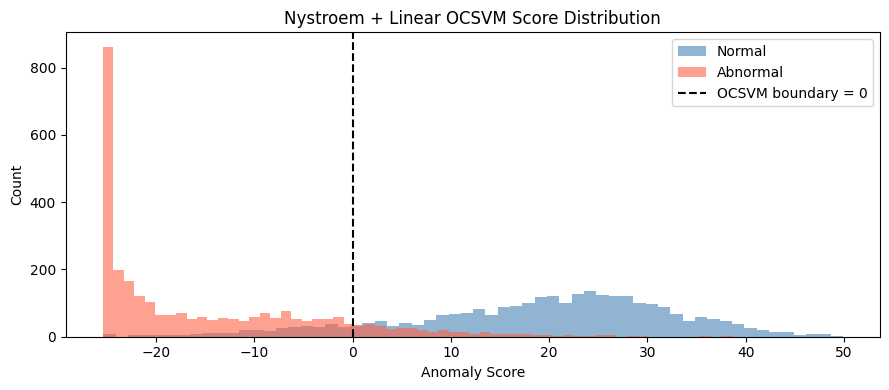


--- Evaluation voi THRESHOLD_2 = 6.0 ---
              precision    recall  f1-score   support

    Abnormal       0.84      0.93      0.88      2889
      Normal       0.93      0.82      0.87      2887

    accuracy                           0.88      5776
   macro avg       0.88      0.88      0.88      5776
weighted avg       0.88      0.88      0.88      5776

Saved: scaler.pkl, nystroem.pkl, ocsvm_linear.pkl


In [9]:
# ── Cell 6: Train Nystroem + Linear OCSVM (Phase 6 & 7) ──────────────────────
# Thay RBF OCSVM (1226 SVs, 660KB) bang Nystroem approximation + linear OCSVM
# => Chi can luu ma tran chieu Nystroem + vector weight tuyen tinh

from sklearn.kernel_approximation import Nystroem
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

N_COMPONENTS = 200  # So chieu kernel xap xi (dieu chinh: 32-128)

# 1. Fit Nystroem tren training data
# gamma='scale' khong duoc ho tro boi Nystroem, tinh thu cong
gamma_value = 1.0 / (X_train_scaled.shape[1] * X_train_scaled.var())
print(f"Computed gamma (scale): {gamma_value:.10f}")

nystroem = Nystroem(kernel='rbf', gamma=gamma_value, n_components=N_COMPONENTS, random_state=42)
X_train_nys = nystroem.fit_transform(X_train_scaled)

# 2. Transform val/test
X_val_normal_nys   = nystroem.transform(X_val_normal_scaled)
X_val_abnormal_nys = nystroem.transform(X_val_abnormal_scaled)
X_test_normal_nys  = nystroem.transform(X_test_normal_scaled)
X_test_abnormal_nys= nystroem.transform(X_test_abnormal_scaled)

# 3. Train linear OCSVM tren khong gian xap xi
ocsvm = OneClassSVM(kernel='linear', nu=0.05)
ocsvm.fit(X_train_nys)
print("Nystroem + Linear OCSVM trained.")
print(f"  Nystroem components: {N_COMPONENTS}")
print(f"  Nystroem gamma: {nystroem.gamma}")

# 4. Score
score_val_normal   = ocsvm.decision_function(X_val_normal_nys)
score_val_abnormal = ocsvm.decision_function(X_val_abnormal_nys)

print(f"\nVal Normal   -- mean: {score_val_normal.mean():.4f}, std: {score_val_normal.std():.4f}")
if score_val_abnormal.shape[0] > 0:
    print(f"Val Abnormal -- mean: {score_val_abnormal.mean():.4f}, std: {score_val_abnormal.std():.4f}")

# 5. Visualize
plt.figure(figsize=(9, 4))
plt.hist(score_val_normal,   bins=60, alpha=0.6, label="Normal",   color="steelblue")
if score_val_abnormal.shape[0] > 0:
    plt.hist(score_val_abnormal, bins=60, alpha=0.6, label="Abnormal", color="tomato")
plt.axvline(0, color="black", linestyle="--", label="OCSVM boundary = 0")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Nystroem + Linear OCSVM Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Threshold
THRESHOLD_1 = -5.0
THRESHOLD_2 = 6.0


if score_val_abnormal.shape[0] > 0:
    y_true = np.concatenate([
        np.ones(len(score_val_normal)),
        -np.ones(len(score_val_abnormal))
    ])
    y_pred = np.where(
        np.concatenate([score_val_normal, score_val_abnormal]) < THRESHOLD_2,
        -1, 1
    )
    print(f"\n--- Evaluation voi THRESHOLD_2 = {THRESHOLD_2} ---")
    print(classification_report(y_true, y_pred, target_names=["Abnormal", "Normal"]))

# 7. Save
os.makedirs("saved_models", exist_ok=True)
joblib.dump(scaler, "saved_models/scaler.pkl")
joblib.dump(nystroem, "saved_models/nystroem.pkl")
joblib.dump(ocsvm, "saved_models/ocsvm_linear.pkl")
print("Saved: scaler.pkl, nystroem.pkl, ocsvm_linear.pkl")


MODEL VALIDATION (Test Set)
Test Normal   -- count: 2938, mean: 19.2231, std: 12.6439
Test Abnormal -- count: 2951, mean: -15.1342, std: 11.5447

Best threshold (F1 scan): 3.8212  (F1=0.9102)

--- Classification Report (threshold = 3.8212) ---
              precision    recall  f1-score   support

    Abnormal       0.90      0.92      0.91      2951
      Normal       0.92      0.89      0.91      2938

    accuracy                           0.91      5889
   macro avg       0.91      0.91      0.91      5889
weighted avg       0.91      0.91      0.91      5889

Confusion Matrix:
                  Pred Abnormal  Pred Normal
  True Abnormal           2727          224
  True Normal              314         2624

THRESHOLD_1 = -5.0000 -> F1=0.8650, TP=2364, FN=587, FP=151, TN=2787

THRESHOLD_2 = 6.0000 -> F1=0.9090, TP=2783, FN=168, FP=389, TN=2549


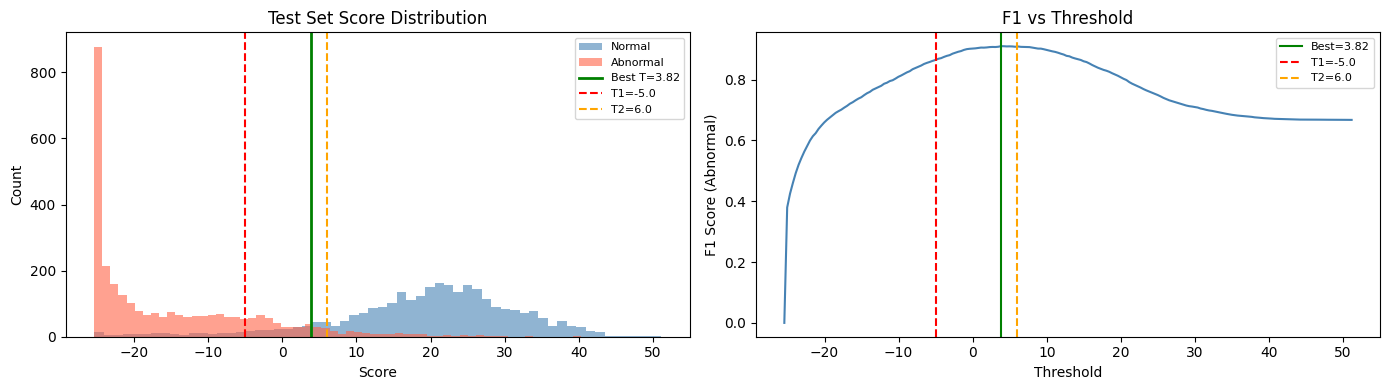


>>> Goi y: Dat THRESHOLD_2 = 3.8212 de can bang F1.
>>> Sau khi hai long, chay Cell 7 de export model.h


In [10]:
# ── Cell 6b: Validate Model Before Export ─────────────────────────────────────
# Kiem tra chat luong Nystroem + Linear OCSVM tren tap Test truoc khi export

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import numpy as np

# --- Transform test data (phong truong hop Cell 6 chua co) ---
X_test_normal_nys   = nystroem.transform(X_test_normal_scaled)
X_test_abnormal_nys = nystroem.transform(X_test_abnormal_scaled)

# --- Score tren Test set ---
score_test_normal   = ocsvm.decision_function(X_test_normal_nys)
score_test_abnormal = ocsvm.decision_function(X_test_abnormal_nys)

print("=" * 60)
print("MODEL VALIDATION (Test Set)")
print("=" * 60)
print(f"Test Normal   -- count: {len(score_test_normal)}, mean: {score_test_normal.mean():.4f}, std: {score_test_normal.std():.4f}")
if len(score_test_abnormal) > 0:
    print(f"Test Abnormal -- count: {len(score_test_abnormal)}, mean: {score_test_abnormal.mean():.4f}, std: {score_test_abnormal.std():.4f}")

# --- Tim threshold toi uu bang F1 scan ---
if len(score_test_abnormal) > 0:
    all_scores = np.concatenate([score_test_normal, score_test_abnormal])
    y_true = np.concatenate([np.ones(len(score_test_normal)),
                             -np.ones(len(score_test_abnormal))])

    thresholds = np.linspace(all_scores.min(), all_scores.max(), 200)
    f1_scores = []
    for t in thresholds:
        y_pred = np.where(all_scores < t, -1, 1)
        f1_scores.append(f1_score(y_true, y_pred, pos_label=-1, zero_division=0))

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"\nBest threshold (F1 scan): {best_threshold:.4f}  (F1={best_f1:.4f})")

    # --- Report voi best threshold ---
    y_pred_best = np.where(all_scores < best_threshold, -1, 1)
    print(f"\n--- Classification Report (threshold = {best_threshold:.4f}) ---")
    print(classification_report(y_true, y_pred_best, target_names=["Abnormal", "Normal"]))

    cm = confusion_matrix(y_true, y_pred_best, labels=[-1, 1])
    print("Confusion Matrix:")
    print(f"  {'':15s} Pred Abnormal  Pred Normal")
    print(f"  {'True Abnormal':15s} {cm[0,0]:>12d}  {cm[0,1]:>11d}")
    print(f"  {'True Normal':15s} {cm[1,0]:>12d}  {cm[1,1]:>11d}")

    # --- Report voi THRESHOLD_1 va THRESHOLD_2 ---
    for name, t in [("THRESHOLD_1", THRESHOLD_1), ("THRESHOLD_2", THRESHOLD_2)]:
        y_p = np.where(all_scores < t, -1, 1)
        f1 = f1_score(y_true, y_p, pos_label=-1, zero_division=0)
        tp = np.sum((y_true == -1) & (y_p == -1))
        fn = np.sum((y_true == -1) & (y_p == 1))
        fp = np.sum((y_true == 1) & (y_p == -1))
        tn = np.sum((y_true == 1) & (y_p == 1))
        print(f"\n{name} = {t:.4f} -> F1={f1:.4f}, TP={tp}, FN={fn}, FP={fp}, TN={tn}")

    # --- Visualize ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Score distribution
    axes[0].hist(score_test_normal,   bins=60, alpha=0.6, label="Normal",   color="steelblue")
    axes[0].hist(score_test_abnormal, bins=60, alpha=0.6, label="Abnormal", color="tomato")
    axes[0].axvline(best_threshold, color="green", linestyle="-", linewidth=2, label=f"Best T={best_threshold:.2f}")
    axes[0].axvline(THRESHOLD_1, color="red",   linestyle="--", label=f"T1={THRESHOLD_1}")
    axes[0].axvline(THRESHOLD_2, color="orange", linestyle="--", label=f"T2={THRESHOLD_2}")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Test Set Score Distribution")
    axes[0].legend(fontsize=8)

    # F1 vs Threshold
    axes[1].plot(thresholds, f1_scores, color="steelblue")
    axes[1].axvline(best_threshold, color="green", linestyle="-", label=f"Best={best_threshold:.2f}")
    axes[1].axvline(THRESHOLD_1, color="red",   linestyle="--", label=f"T1={THRESHOLD_1}")
    axes[1].axvline(THRESHOLD_2, color="orange", linestyle="--", label=f"T2={THRESHOLD_2}")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("F1 Score (Abnormal)")
    axes[1].set_title("F1 vs Threshold")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- Goi y ---
    print("\n>>> Goi y: Dat THRESHOLD_2 = {:.4f} de can bang F1.".format(best_threshold))
    print(">>> Sau khi hai long, chay Cell 7 de export model.h")
else:
    print("\nKhong co abnormal data de danh gia. Chi co Normal distribution.")
    plt.figure(figsize=(7, 3))
    plt.hist(score_test_normal, bins=60, alpha=0.7, color="steelblue")
    plt.axvline(0, color="black", linestyle="--")
    plt.title("Test Normal Score Distribution")
    plt.show()


In [11]:
# ── Cell 7: Export Nystroem + Linear OCSVM to C header (Phase 9) ──────────────
# Pipeline ESP32: Scale -> Nystroem transform -> dot(w, x) + intercept
#
# Nystroem transform(x):
#   1. Compute k[j] = exp(-gamma * ||x - component[j]||^2)  for j in [0, N_COMP)
#   2. z = normalization @ k   (N_COMP x N_COMP matrix times N_COMP vector)
#
# Linear OCSVM: score = dot(w, z) + intercept

import os
import numpy as np

os.makedirs("saved_models", exist_ok=True)
header_path = "saved_models/model.h"

# --- Lay thong so ---
components = nystroem.components_             # (N_COMP, 39)
normalization = nystroem.normalization_.T      # (N_COMP, N_COMP) - luu row-major
gamma_val = nystroem.gamma                    # scalar
n_comp = components.shape[0]
n_feat = components.shape[1]

w = ocsvm.coef_[0]                            # (N_COMP,)
intercept = ocsvm.intercept_[0]               # scalar

print(f"Nystroem components : {n_comp} x {n_feat}")
print(f"Gamma               : {gamma_val:.10f}")
print(f"Linear weights      : {w.shape[0]}")
print(f"Intercept           : {intercept:.10f}")

# --- Helper ---
def to_c_array(arr, name, dtype="float"):
    flat = arr.flatten()
    vals = ", ".join([f"{v:.8f}f" for v in flat])
    return f"const {dtype} {name}[{len(flat)}] = {{{vals}}};\n"

# --- Estimate size ---
total_floats = (n_comp * n_feat) + (n_comp * n_comp) + n_comp + n_feat * 2
est_kb = total_floats * 4 / 1024
print(f"\nEstimated model size : {est_kb:.1f} KB (vs 660KB before)")

# --- Write header ---
with open(header_path, "w") as f:
    f.write("#pragma once\n\n")
    f.write("// Auto-generated Nystroem + Linear OCSVM model for ESP32\n")
    f.write(f"// Nystroem components: {n_comp}, Features: {n_feat}\n\n")

    f.write(f"const int N_FEATURES = {n_feat};\n")
    f.write(f"const int N_COMPONENTS = {n_comp};\n")
    f.write(f"const float GAMMA = {gamma_val:.10f}f;\n")
    f.write(f"const float INTERCEPT = {intercept:.10f}f;\n")
    f.write(f"const float THRESHOLD_1 = {THRESHOLD_1:.4f}f;\n")
    f.write(f"const float THRESHOLD_2 = {THRESHOLD_2:.4f}f;\n\n")

    # Scaler
    f.write("// StandardScaler\n")
    f.write(to_c_array(scaler.mean_, "SCALER_MEAN"))
    f.write(to_c_array(scaler.scale_, "SCALER_SCALE"))
    f.write("\n")

    # Nystroem components: N_COMP x N_FEAT (row-major)
    f.write(f"// Nystroem components: {n_comp} x {n_feat} (row-major)\n")
    f.write(to_c_array(components, "NYS_COMPONENTS"))
    f.write("\n")

    # Nystroem normalization: N_COMP x N_COMP (row-major)
    f.write(f"// Nystroem normalization: {n_comp} x {n_comp} (row-major)\n")
    f.write(to_c_array(normalization, "NYS_NORMALIZATION"))
    f.write("\n")

    # Linear SVM weights
    f.write("// Linear OCSVM weights\n")
    f.write(to_c_array(w, "SVM_W"))
    f.write("\n")

    # Pseudocode
    f.write("/*\n")
    f.write(" * inference(x[N_FEATURES]):\n")
    f.write(" *   1. x_s[i] = (x[i] - SCALER_MEAN[i]) / SCALER_SCALE[i]\n")
    f.write(" *   2. For j in [0, N_COMPONENTS):\n")
    f.write(" *        diff = sum((x_s[i] - NYS_COMPONENTS[j*N_FEATURES+i])^2)\n")
    f.write(" *        k[j] = exp(-GAMMA * diff)\n")
    f.write(" *   3. For j in [0, N_COMPONENTS):\n")
    f.write(" *        z[j] = sum(NYS_NORMALIZATION[j*N_COMPONENTS+m] * k[m])\n")
    f.write(" *   4. score = sum(SVM_W[j] * z[j]) + INTERCEPT\n")
    f.write(" *   5. if score < THRESHOLD_1 -> immediate alert\n")
    f.write(" *      if score < THRESHOLD_2 for 3 frames -> sustained alert\n")
    f.write(" */\n")

print(f"\nExported: {header_path}")
print(f"File size: {os.path.getsize(header_path) / 1024:.1f} KB")


Nystroem components : 200 x 39
Gamma               : 0.0256410260
Linear weights      : 200
Intercept           : -25.4315152760

Estimated model size : 187.8 KB (vs 660KB before)

Exported: saved_models/model.h
File size: 634.7 KB
